In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, f1_score, accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt

# Загрузка и предобработка датасетов

Предобработка была выполнена аналогично предобработке в ЛР№1 по ML, конкретнее в [Алмазы](D:/Python/OmSTU/NLP/lab_1/lab_1_1.ipynb), [Фрод](D:/Python/OmSTU/NLP/lab_1/lab_1_2.ipynb)

# Подготовка DataLoader'ов

In [2]:
class SimpleDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

In [3]:
def prepare_train_test_loaders(path, target, test_size=0.2, val_size=0.2, 
                               batch_size=32, shuffle=True, stratify=None, 
                               random_state=42, is_classification=False):
    
    data = pd.read_csv(path)
    X = data.drop(target, axis=1)
    y = data[target]

    feature_names = X.columns.tolist()
    print(f"Features: {feature_names}")
    print(f"Target: {target}")
    print(f"Original data shape: {X.shape}")
    print(f"Is classification: {is_classification}")

    if is_classification:
        print("Original class distribution:")
        print(y.value_counts())

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, 
        test_size=test_size, 
        random_state=random_state, 
        shuffle=shuffle, 
        stratify=y if stratify else None
    )

    val_ratio = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, 
        test_size=val_ratio,
        random_state=random_state, 
        shuffle=shuffle, 
        stratify=y_temp if stratify and not is_classification else None
    )

    if is_classification:
        print("Before SMOTE - Train class distribution:")
        print(pd.Series(y_train).value_counts())

        smote = SMOTE(random_state=random_state)
        X_train, y_train = smote.fit_resample(X_train, y_train)
        
        print("After SMOTE - Train class distribution:")
        print(pd.Series(y_train).value_counts())
    
    print(f"Train shape: {X_train.shape}")
    print(f"Val shape: {X_val.shape}")
    print(f"Test shape: {X_test.shape}")

    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_val_scaled = scaler_X.transform(X_val)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_2d = np.array(y_train).reshape(-1, 1)
    y_val_2d = np.array(y_val).reshape(-1, 1)
    y_test_2d = np.array(y_test).reshape(-1, 1)

    train_dataset = SimpleDataset(X_train_scaled, y_train_2d)
    val_dataset = SimpleDataset(X_val_scaled, y_val_2d)
    test_dataset = SimpleDataset(X_test_scaled, y_test_2d)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    result = {
        'train_loader': train_loader,
        'val_loader': val_loader,
        'test_loader': test_loader,
        'scaler_X': scaler_X,
        'feature_names': feature_names,
        'is_classification': is_classification
    }

    return result

In [4]:
regr_res = prepare_train_test_loaders(r'D:\Python\OmSTU\NLP\lab_1\data\post_diamonds.csv', 'price')
train_regr = regr_res['train_loader']
val_regr = regr_res['val_loader']
test_regr = regr_res['test_loader']

Features: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']
Target: price
Original data shape: (53794, 9)
Is classification: False
Train shape: (32276, 9)
Val shape: (10759, 9)
Test shape: (10759, 9)


In [5]:
clas_res = prepare_train_test_loaders(r'D:\Python\OmSTU\NLP\lab_1\data\post_card_transdata.csv', 'fraud', stratify=True, is_classification=True)
train_clas = clas_res['train_loader']
val_clas = clas_res['val_loader']
test_clas = clas_res['test_loader']

Features: ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']
Target: fraud
Original data shape: (1000000, 7)
Is classification: True
Original class distribution:
fraud
0    912597
1     87403
Name: count, dtype: int64
Before SMOTE - Train class distribution:
fraud
0    547674
1     52326
Name: count, dtype: int64
After SMOTE - Train class distribution:
fraud
0    547674
1    547674
Name: count, dtype: int64
Train shape: (1095348, 7)
Val shape: (200000, 7)
Test shape: (200000, 7)


In [6]:
for batch in train_regr:
    features, targets = batch
    print(f"Features shape: {features.shape}, Targets shape: {targets.shape}")
    break

Features shape: torch.Size([32, 9]), Targets shape: torch.Size([32, 1])


In [7]:
for batch in train_clas:
    features, targets = batch
    print(f"Features shape: {features.shape}, Targets shape: {targets.shape}")
    break

Features shape: torch.Size([32, 7]), Targets shape: torch.Size([32, 1])


# Создание FCNN

В IV семестре на дисциплине **Машинное обучение** были выполнены лабораторные работы, где для этих датасетов собирались FCNN с подбором гиперпараметров. Я взял гиперпараметры, полученные своим честным трудом и на их основе собрал FCNN на базе `torch`.

## Регрессия

In [8]:
class RegressionModel(nn.Module):
    def __init__(self, input_dim, hidden_size1=150, hidden_size2=150):
        
        super(RegressionModel, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_size1),
            nn.ReLU(),
            nn.Linear(hidden_size1, hidden_size2),
            nn.ReLU(),
            nn.Linear(hidden_size2, 1)
        )
    
    def forward(self, x):
        return self.model(x)

## Классификация (бинарная)

In [15]:
class ClassificationModel(nn.Module):
    def __init__(self, input_dim, hidden_size1=150, hidden_size2=125, num_classes=2):
        super(ClassificationModel, self).__init__()
        self.num_classes = num_classes
        
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_size1),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size1, hidden_size2), 
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size2, num_classes)
        )
    
    def forward(self, x):
        return self.model(x)
    
    def predict_proba(self, x):
        with torch.no_grad():
            logits = self.model(x)
            return nn.functional.softmax(logits, dim=1)

# Обучение нейросетей

## Регрессия

In [10]:
def train_epoch(model, train_loader, optimizer, criterion):
    model.train()
    total_loss = 0
    
    for _, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

def validate_epoch(model, val_loader, criterion):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for data, target in val_loader:
            output = model(data)
            total_loss += criterion(output, target).item()
    
    return total_loss / len(val_loader)

In [11]:
model_regr = RegressionModel(9)
print(model_regr)

criterion_regr = nn.MSELoss()
optimizer_regr = optim.RMSprop(model_regr.parameters(), lr=0.01, alpha=0.9, momentum=0.2, weight_decay=0)
scheduler_regr = optim.lr_scheduler.ReduceLROnPlateau(optimizer_regr, mode='min', factor=0.5, patience=10)

RegressionModel(
  (model): Sequential(
    (0): Linear(in_features=9, out_features=150, bias=True)
    (1): ReLU()
    (2): Linear(in_features=150, out_features=150, bias=True)
    (3): ReLU()
    (4): Linear(in_features=150, out_features=1, bias=True)
  )
)


In [139]:
num_epochs = 50
train_losses = []
val_losses = []
best_val_loss = float('inf')

for epoch in range(num_epochs):
    train_loss = train_epoch(model_regr, train_regr, optimizer_regr, criterion_regr)
    val_loss = validate_epoch(model_regr, val_regr, criterion_regr)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    scheduler_regr.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_regr.state_dict(), 'best_model_regr.pth')
        print(f'↳ New best model! RMSE: {np.sqrt(val_loss):.4f}')

    print(f'Epoch [{epoch+1:03d}/{num_epochs}] | '
            f'Train Loss (RMSE): {np.sqrt(train_loss):.4f} | '
            f'Val Loss (RMSE): {np.sqrt(val_loss):.4f}')

↳ New best model! RMSE: 1213.8504
Epoch [001/50] | Train Loss (RMSE): 1182.0724 | Val Loss (RMSE): 1213.8504
↳ New best model! RMSE: 1136.6250
Epoch [002/50] | Train Loss (RMSE): 867.4143 | Val Loss (RMSE): 1136.6250
Epoch [003/50] | Train Loss (RMSE): 823.5395 | Val Loss (RMSE): 1165.3188
Epoch [004/50] | Train Loss (RMSE): 815.9307 | Val Loss (RMSE): 1209.7294
Epoch [005/50] | Train Loss (RMSE): 801.5304 | Val Loss (RMSE): 1181.4367
↳ New best model! RMSE: 1125.9091
Epoch [006/50] | Train Loss (RMSE): 793.2538 | Val Loss (RMSE): 1125.9091
↳ New best model! RMSE: 1097.8514
Epoch [007/50] | Train Loss (RMSE): 771.3841 | Val Loss (RMSE): 1097.8514
↳ New best model! RMSE: 1085.3655
Epoch [008/50] | Train Loss (RMSE): 755.9312 | Val Loss (RMSE): 1085.3655
Epoch [009/50] | Train Loss (RMSE): 732.4696 | Val Loss (RMSE): 1258.7258
↳ New best model! RMSE: 1053.2682
Epoch [010/50] | Train Loss (RMSE): 725.2521 | Val Loss (RMSE): 1053.2682
↳ New best model! RMSE: 995.1255
Epoch [011/50] | Train

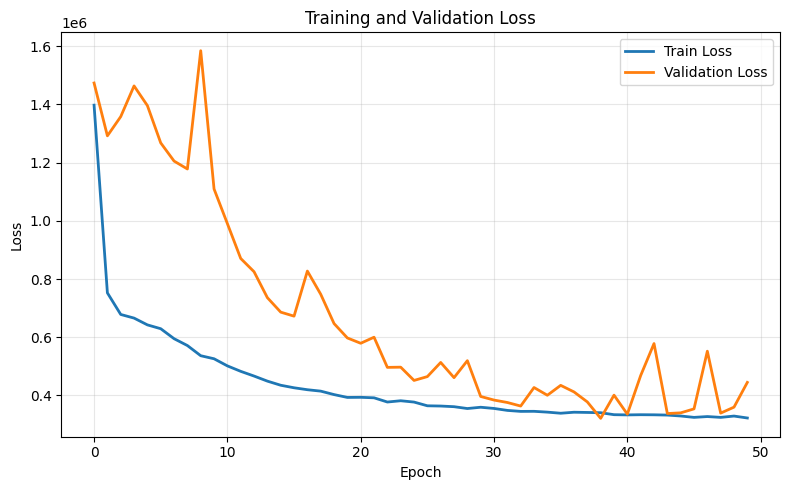

Best validation loss: 321333.8046


In [140]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Best validation loss: {best_val_loss:.4f}')

## Классификация

In [16]:
model_clas = ClassificationModel(7)
print(model_clas)

criterion_clas = nn.CrossEntropyLoss()
optimizer_clas = torch.optim.Adam(model_clas.parameters(), lr=0.0001, betas=(0.82, 0.95))
scheduler_clas = optim.lr_scheduler.ReduceLROnPlateau(optimizer_clas, mode='min', factor=0.5, patience=10)

ClassificationModel(
  (model): Sequential(
    (0): Linear(in_features=7, out_features=150, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=150, out_features=125, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=125, out_features=2, bias=True)
  )
)


In [17]:
def train_epoch(model, train_loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for data, target in train_loader:
        target = target.long().squeeze()
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        probs = nn.functional.softmax(output, dim=1)
        predicted = torch.argmax(probs, dim=1)
        correct += (predicted == target).sum().item()
        total += target.size(0)
    
    accuracy = correct / total
    return total_loss / len(train_loader), accuracy

def validate_epoch(model, val_loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in val_loader:
            target = target.long().squeeze()
            
            output = model(data)
            loss = criterion(output, target)
            total_loss += loss.item()
            
            probs = nn.functional.softmax(output, dim=1)
            predicted = torch.argmax(probs, dim=1)
            correct += (predicted == target).sum().item()
            total += target.size(0)
    
    accuracy = correct / total
    return total_loss / len(val_loader), accuracy

def calculate_f1(model, data_loader):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in data_loader:
            target = target.long().squeeze()
            output = model(data)
            probs = nn.functional.softmax(output, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    return f1_score(all_targets, all_preds, zero_division=0)

In [ ]:
num_epochs = 20
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_f1_scores = []
val_f1_scores = []
best_val_f1 = 0.0
best_val_loss = float('inf')

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model_clas, train_clas, optimizer_clas, criterion_clas)
    val_loss, val_acc = validate_epoch(model_clas, val_clas, criterion_clas)
    train_f1 = calculate_f1(model_clas, train_clas)
    val_f1 = calculate_f1(model_clas, val_clas)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    train_f1_scores.append(train_f1)
    val_f1_scores.append(val_f1)
    
    scheduler_clas.step(val_loss)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_val_loss = val_loss
        torch.save(model_clas.state_dict(), 'best_model_clas.pth')
        print(f'↳ New best model! F1: {val_f1:.4f}')

    print(f'Epoch [{epoch+1:03d}/{num_epochs}] | '
          f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | '
          f'Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f} | '
          f'Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}')

↳ New best model! F1: 0.9365
Epoch [001/20] | Train Loss: 0.0664 | Val Loss: 0.0340 | Train Acc: 0.979 | Val Acc: 0.988 | Train F1: 0.9928 | Val F1: 0.9365
↳ New best model! F1: 0.9456
Epoch [002/20] | Train Loss: 0.0310 | Val Loss: 0.0308 | Train Acc: 0.991 | Val Acc: 0.990 | Train F1: 0.9939 | Val F1: 0.9456
↳ New best model! F1: 0.9593
Epoch [003/20] | Train Loss: 0.0254 | Val Loss: 0.0244 | Train Acc: 0.993 | Val Acc: 0.993 | Train F1: 0.9954 | Val F1: 0.9593
Epoch [004/20] | Train Loss: 0.0222 | Val Loss: 0.0276 | Train Acc: 0.994 | Val Acc: 0.992 | Train F1: 0.9952 | Val F1: 0.9559
↳ New best model! F1: 0.9657
Epoch [005/20] | Train Loss: 0.0196 | Val Loss: 0.0204 | Train Acc: 0.995 | Val Acc: 0.994 | Train F1: 0.9962 | Val F1: 0.9657
↳ New best model! F1: 0.9730
Epoch [006/20] | Train Loss: 0.0179 | Val Loss: 0.0163 | Train Acc: 0.995 | Val Acc: 0.995 | Train F1: 0.9968 | Val F1: 0.9730
↳ New best model! F1: 0.9731
Epoch [007/20] | Train Loss: 0.0172 | Val Loss: 0.0194 | Train A

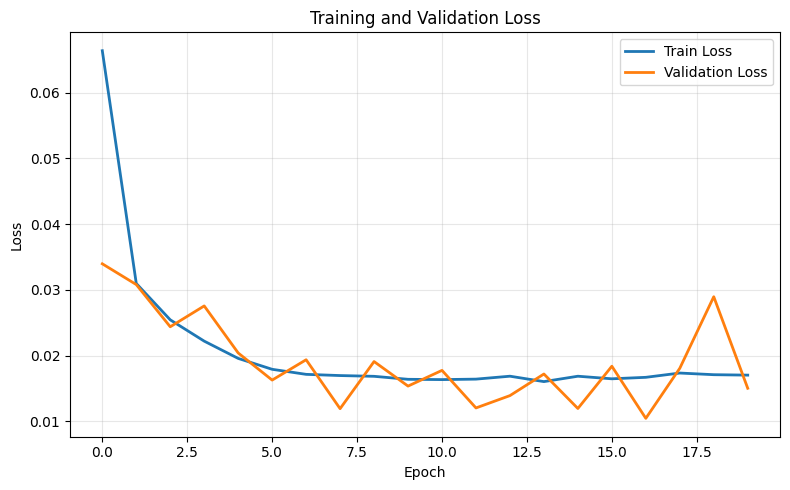

Best validation loss: 0.0105


In [19]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Best validation loss: {best_val_loss:.4f}')

# Оценка результатов

## Регрессия

In [141]:
def test_model(model, test_loader):
    model.eval()
    predictions = []
    true_values = []
    
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            predictions.append(output.numpy())
            true_values.append(target.numpy())

    predictions = np.vstack(predictions)
    true_values = np.vstack(true_values)

    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    mae = mean_absolute_error(true_values, predictions)
    r2 = r2_score(true_values, predictions)
    
    return {
        'predictions': predictions,
        'true_values': true_values,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    }

In [142]:
model_regr.load_state_dict(torch.load('best_model_regr.pth'))

results = test_model(model_regr, test_regr)

print(f"Test RMSE: {results['rmse']:.4f}")
print(f"Test MAE: {results['mae']:.4f}")
print(f"Test R²: {results['r2']:.4f}")

Test RMSE: 525.9568
Test MAE: 290.6977
Test R²: 0.9819


## Классификация

In [ ]:
def test_model_clas(model, test_loader):
    model.eval()
    all_predictions = []
    all_probabilities = []
    all_true_values = []
    
    with torch.no_grad():
        for data, target in test_loader:
            probabilities = model.predict_proba(data)

            pos_probs = probabilities[:, 1]

            predictions = torch.argmax(probabilities, dim=1)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(pos_probs.cpu().numpy())
            all_true_values.extend(target.cpu().numpy())

    predictions = np.array(all_predictions).flatten()
    probabilities = np.array(all_probabilities).flatten()
    true_values = np.array(all_true_values).flatten()

    accuracy = accuracy_score(true_values, predictions)
    precision = precision_score(true_values, predictions, zero_division=0)
    recall = recall_score(true_values, predictions, zero_division=0)
    f1 = f1_score(true_values, predictions, zero_division=0)

    return {
        'predictions': predictions,
        'probabilities': probabilities,
        'true_values': true_values,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

In [24]:
model_clas.load_state_dict(torch.load('best_model_clas.pth'))

results = test_model_clas(model_clas, test_clas)

print(f"Test Accuracy: {results['accuracy']:.4f}")
print(f"Test Precision: {results['precision']:.4f}")
print(f"Test Recall: {results['recall']:.4f}")
print(f"Test F1-score: {results['f1_score']:.4f}")

Test Accuracy: 0.9973
Test Precision: 0.9737
Test Recall: 0.9962
Test F1-score: 0.9848
